# Predictive Paradox — Complete Pipeline
**Bangladesh Power Demand Forecasting**

End-to-end pipeline covering EDA, preprocessing, feature engineering, model selection, cross-validation, and hyperparameter tuning.

> **Required files:** `PGCB_date_power_demand.xlsx`, `weather_data.xlsx`, `economic_full_1.csv`

## Section 0 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
import time
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

---
## Section 1 — Exploratory Data Analysis

### 1.1 Load Datasets

In [2]:
df_power   = pd.read_excel("PGCB_date_power_demand.xlsx")
df_weather = pd.read_excel("weather_data.xlsx", header=3)
df_eco     = pd.read_csv("economic_full_1.csv")

df_power["datetime"]  = pd.to_datetime(df_power["datetime"])
df_weather["time"]    = pd.to_datetime(df_weather["time"])

print(f"Power   : {df_power.shape[0]:,} rows x {df_power.shape[1]} cols  |  "
      f"{df_power['datetime'].min().date()} -> {df_power['datetime'].max().date()}")
print(f"Weather : {df_weather.shape[0]:,} rows x {df_weather.shape[1]} cols  |  "
      f"{df_weather['time'].min().date()} -> {df_weather['time'].max().date()}")
print(f"Economic: {df_eco.shape[0]:,} rows x {df_eco.shape[1]} cols")

Power   : 92,650 rows x 15 cols  |  2015-04-19 -> 2025-06-17
Weather : 107,304 rows x 10 cols  |  2014-01-01 -> 2026-03-29
Economic: 1,516 rows x 69 cols


### 1.2 Power Demand — Structure & Missing Values

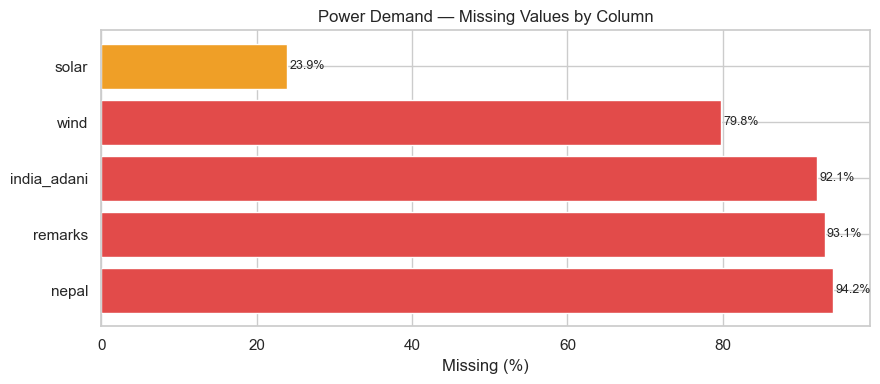

Red > 50% -> DROP | Orange > 10% -> IMPUTE | Green -> OK


In [3]:
missing = df_power.isnull().sum()
missing_pct = (missing / len(df_power) * 100).round(1)
missing_df = pd.DataFrame({"Count": missing, "Pct": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#E24B4A" if p > 50 else "#EF9F27" if p > 10 else "#1D9E75"
          for p in missing_df["Pct"]]
bars = ax.barh(missing_df.index, missing_df["Pct"], color=colors)
ax.set_xlabel("Missing (%)")
ax.set_title("Power Demand — Missing Values by Column")
for bar, pct in zip(bars, missing_df["Pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Red > 50% -> DROP | Orange > 10% -> IMPUTE | Green -> OK")

### 1.3 Power Demand — Time Patterns

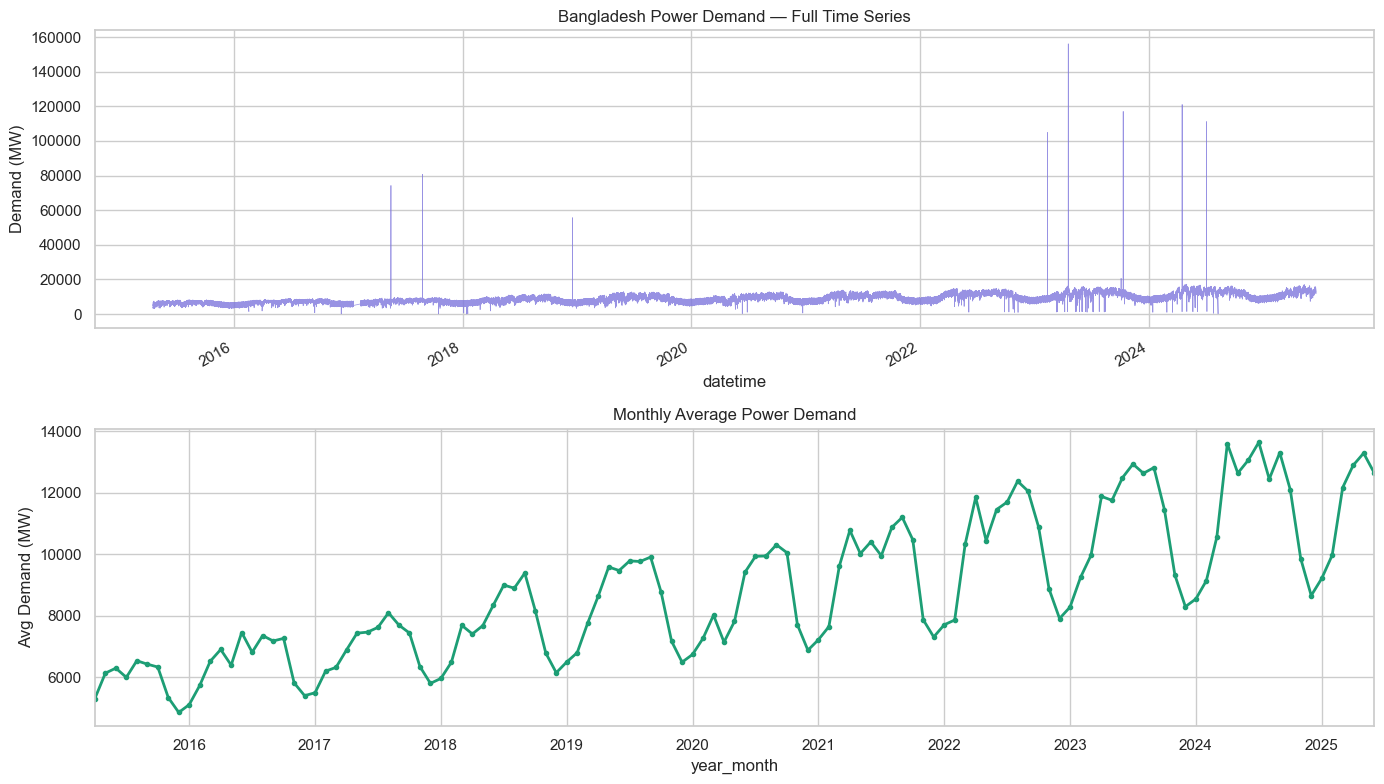

In [4]:
df_power["hour"]  = df_power["datetime"].dt.hour
df_power["month"] = df_power["datetime"].dt.month
df_power["year"]  = df_power["datetime"].dt.year
df_power["dow"]   = df_power["datetime"].dt.dayofweek

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_power.set_index("datetime")["demand_mw"].plot(
    ax=axes[0], color="#7F77DD", linewidth=0.5, alpha=0.8)
axes[0].set_title("Bangladesh Power Demand — Full Time Series")
axes[0].set_ylabel("Demand (MW)")

df_power["year_month"] = df_power["datetime"].dt.to_period("M")
monthly_avg = df_power.groupby("year_month")["demand_mw"].mean()
monthly_avg.plot(ax=axes[1], color="#1D9E75", linewidth=2, marker="o", markersize=3)
axes[1].set_title("Monthly Average Power Demand")
axes[1].set_ylabel("Avg Demand (MW)")

plt.tight_layout()
plt.show()

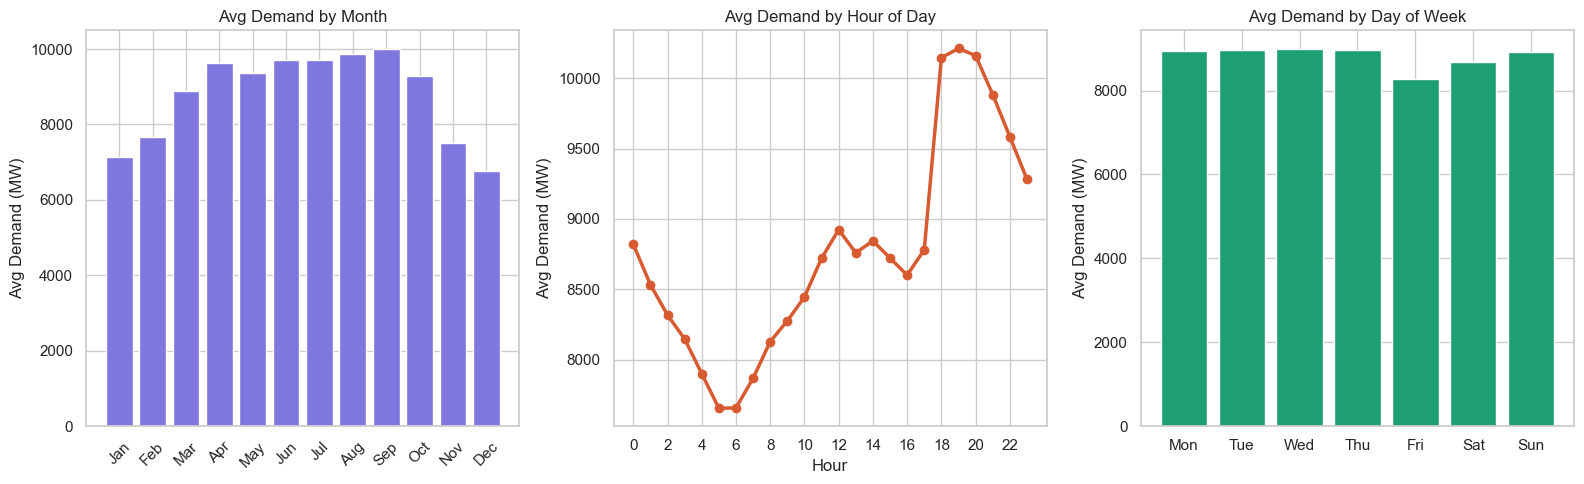

In [5]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
dow_names   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

monthly = df_power.groupby("month")["demand_mw"].mean()
axes[0].bar(monthly.index, monthly.values, color="#7F77DD", edgecolor="white")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].set_title("Avg Demand by Month")
axes[0].set_ylabel("Avg Demand (MW)")

hourly = df_power.groupby("hour")["demand_mw"].mean()
axes[1].plot(hourly.index, hourly.values, color="#D85A30", linewidth=2.5, marker="o")
axes[1].set_title("Avg Demand by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg Demand (MW)")
axes[1].set_xticks(range(0, 24, 2))

daily = df_power.groupby("dow")["demand_mw"].mean()
axes[2].bar(dow_names, daily.values, color="#1D9E75", edgecolor="white")
axes[2].set_title("Avg Demand by Day of Week")
axes[2].set_ylabel("Avg Demand (MW)")

plt.tight_layout()
plt.show()

### 1.4 Weather Data

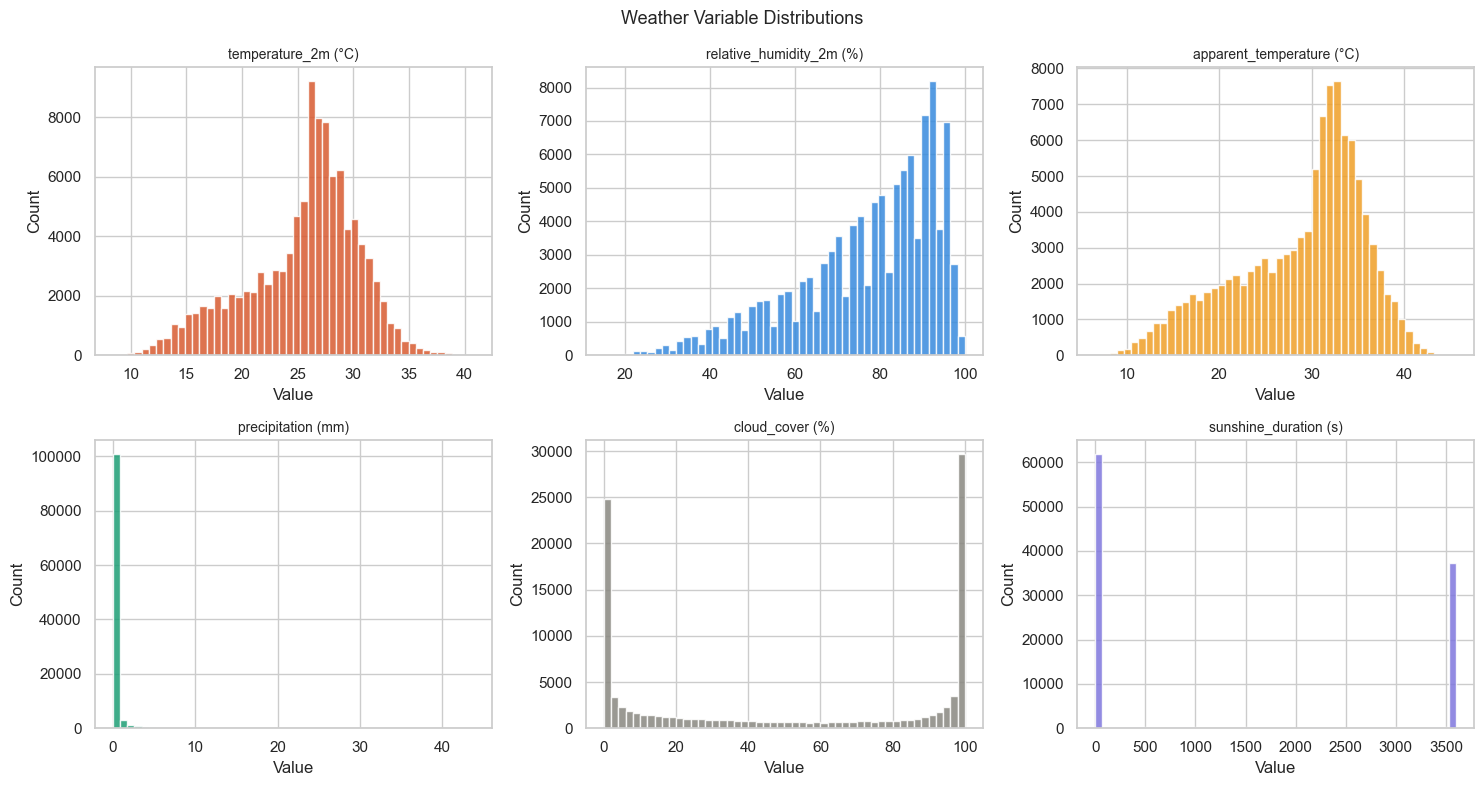

In [6]:
weather_cols = [
    "temperature_2m (°C)", "relative_humidity_2m (%)",
    "apparent_temperature (°C)", "precipitation (mm)",
    "cloud_cover (%)", "sunshine_duration (s)",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors_w = ["#D85A30", "#378ADD", "#EF9F27", "#1D9E75", "#888780", "#7F77DD"]

for i, col in enumerate(weather_cols):
    axes[i].hist(df_weather[col].dropna(), bins=50,
                 color=colors_w[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Weather Variable Distributions", fontsize=13)
plt.tight_layout()
plt.show()

### 1.5 Cross-Dataset: Weather vs Demand

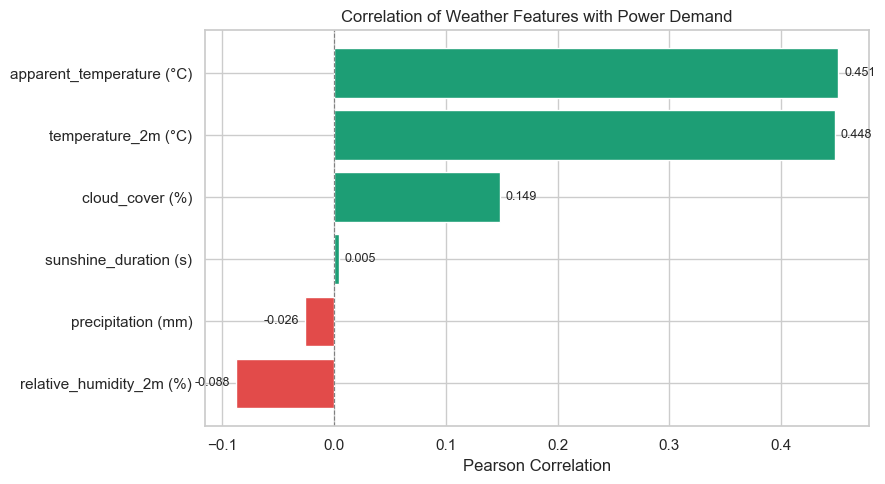

In [7]:
df_weather_s = df_weather.sort_values("time").reset_index(drop=True)
df_power_s   = df_power.sort_values("datetime").reset_index(drop=True)

df_merged_eda = pd.merge_asof(
    df_power_s,
    df_weather_s.rename(columns={"time": "datetime"}),
    on="datetime",
    tolerance=pd.Timedelta("1h"),
    direction="nearest",
)

corr_vals = (df_merged_eda[weather_cols + ["demand_mw"]]
             .corr()["demand_mw"]
             .drop("demand_mw")
             .sort_values())

fig, ax = plt.subplots(figsize=(9, 5))
colors_c = ["#E24B4A" if v < 0 else "#1D9E75" for v in corr_vals]
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors_c)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Correlation of Weather Features with Power Demand")
ax.set_xlabel("Pearson Correlation")
for bar, val in zip(bars, corr_vals.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

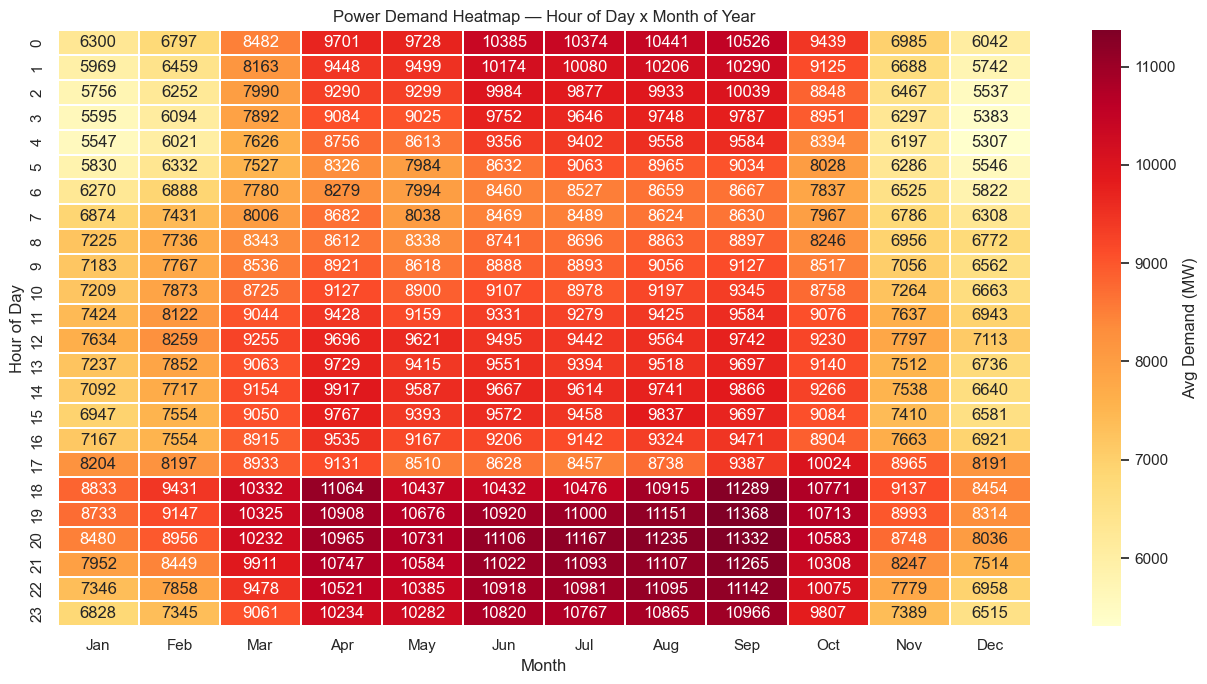

In [8]:
pivot = df_power.pivot_table(
    values="demand_mw", index="hour", columns="month", aggfunc="mean"
)
pivot.columns = month_names

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.3, ax=ax, cbar_kws={"label": "Avg Demand (MW)"})
ax.set_title("Power Demand Heatmap — Hour of Day x Month of Year")
ax.set_ylabel("Hour of Day")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

---
## Section 2 — Data Preprocessing & Feature Engineering

### 2.1 Power Data — Cleaning

In [9]:
# Drop columns with > 80% missing values
DROP_COLS = ["wind", "india_adani", "nepal", "remarks"]
df_power.drop(columns=DROP_COLS, inplace=True, errors="ignore")

# Fix generation_mw data entry error (value ~10000x too large)
df_power.loc[df_power["generation_mw"] > 50_000, "generation_mw"] /= 10_000

# Fix demand_mw truncation errors (values < 1000 MW are physically impossible)
df_power.loc[df_power["demand_mw"] < 1_000, "demand_mw"] = np.nan
df_power["demand_mw"] = df_power["demand_mw"].ffill()

# Impute solar (24% missing) with column median
df_power["solar"] = df_power["solar"].fillna(df_power["solar"].median())

# Winsorize demand_mw outliers using IQR method
Q1, Q3 = df_power["demand_mw"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_power["demand_mw"] = df_power["demand_mw"].clip(
    lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR
)

print(f"Power data cleaned: {df_power.shape[0]:,} rows x {df_power.shape[1]} cols")
print(f"Demand range: {df_power['demand_mw'].min():.0f} – {df_power['demand_mw'].max():.0f} MW")
print(f"Remaining missing values: {df_power.isnull().sum().sum()}")

Power data cleaned: 92,650 rows x 16 cols
Demand range: 1082 – 16366 MW
Remaining missing values: 0


### 2.2 Power Data — Feature Engineering

In [10]:
df_power["hour"]       = df_power["datetime"].dt.hour
df_power["month"]      = df_power["datetime"].dt.month
df_power["year"]       = df_power["datetime"].dt.year
df_power["dow"]        = df_power["datetime"].dt.dayofweek
df_power["quarter"]    = df_power["datetime"].dt.quarter
df_power["is_weekend"] = (df_power["dow"] >= 5).astype(int)

# Bangladesh seasons: Summer Mar-Jun | Monsoon Jul-Oct | Winter Nov-Feb
def assign_season(month):
    if month in [3, 4, 5, 6]:    return "summer"
    elif month in [7, 8, 9, 10]: return "monsoon"
    else:                         return "winter"

df_power["season"] = df_power["month"].apply(assign_season)

# Cyclical encoding preserves the circular nature of time features
df_power["hour_sin"]  = np.sin(2 * np.pi * df_power["hour"]  / 24)
df_power["hour_cos"]  = np.cos(2 * np.pi * df_power["hour"]  / 24)
df_power["month_sin"] = np.sin(2 * np.pi * df_power["month"] / 12)
df_power["month_cos"] = np.cos(2 * np.pi * df_power["month"] / 12)
df_power["dow_sin"]   = np.sin(2 * np.pi * df_power["dow"]   / 7)
df_power["dow_cos"]   = np.cos(2 * np.pi * df_power["dow"]   / 7)

season_dummies = pd.get_dummies(df_power["season"], prefix="season", drop_first=False)
df_power = pd.concat([df_power, season_dummies], axis=1)
df_power.drop(columns=["season"], inplace=True)

print(f"Feature engineering complete. Shape: {df_power.shape}")

Feature engineering complete. Shape: (92650, 27)


### 2.3 Weather Data — Feature Engineering

In [11]:
df_weather = df_weather.sort_values("time").reset_index(drop=True)

# Heat index: combines temperature and humidity into a single thermal load estimate
T = df_weather["temperature_2m (°C)"]
H = df_weather["relative_humidity_2m (%)"]
df_weather["heat_index"] = (
    -8.78469475556
    + 1.61139411   * T
    + 2.33854883889 * H
    + (-0.14611605) * T * H
    + (-0.012308094) * T**2
    + (-0.0164248277778) * H**2
    + 0.002211732  * T**2 * H
    + 0.00072546   * T   * H**2
    + (-0.000003582) * T**2 * H**2
)

# Rolling weather averages: captures the thermal inertia effect on demand
df_weather["temp_24h_avg"]      = df_weather["temperature_2m (°C)"].rolling(24,  min_periods=1).mean()
df_weather["temp_72h_avg"]      = df_weather["temperature_2m (°C)"].rolling(72,  min_periods=1).mean()
df_weather["humidity_24h_avg"]  = df_weather["relative_humidity_2m (%)"].rolling(24, min_periods=1).mean()

print(f"Weather features engineered. Shape: {df_weather.shape}")

Weather features engineered. Shape: (107304, 14)


### 2.4 Economic Data — Reshape & Interpolate

In [12]:
KEY_INDICATORS = [
    "GDP (current US$)",
    "GDP growth (annual %)",
    "GDP per capita (current US$)",
    "Population, total",
    "Urban population",
    "Urban population (% of total population)",
    "Inflation, consumer prices (annual %)",
    "Electric power consumption (kWh per capita)",
    "Access to electricity (% of population)",
    "Industry (including construction), value added (% of GDP)",
]

df_key = df_eco[df_eco["Indicator Name"].isin(KEY_INDICATORS)].copy()
year_cols = [str(y) for y in range(2015, 2024)]
available_years = [y for y in year_cols if y in df_key.columns]
df_key = df_key[["Indicator Name"] + available_years]

# Reshape: wide -> long -> pivot to one column per indicator
df_eco_long = df_key.melt(
    id_vars="Indicator Name", value_vars=available_years,
    var_name="year", value_name="value"
)
df_eco_long["year"] = df_eco_long["year"].astype(int)

df_eco_pivot = df_eco_long.pivot_table(
    index="year", columns="Indicator Name", values="value"
).reset_index()
df_eco_pivot.columns.name = None

# Linear interpolation for sparse yearly values
df_eco_pivot = (df_eco_pivot
                .set_index("year")
                .interpolate(method="linear")
                .reset_index())

print(f"Economic data reshaped: {df_eco_pivot.shape}")
print(f"Missing after interpolation: {df_eco_pivot.isnull().sum().sum()}")

Economic data reshaped: (9, 11)
Missing after interpolation: 0


### 2.5 Merge All Datasets

In [13]:
df_power_s  = df_power.sort_values("datetime").reset_index(drop=True)
df_weather_s = df_weather.sort_values("time").reset_index(drop=True)

df_merged = pd.merge_asof(
    df_power_s,
    df_weather_s.rename(columns={"time": "datetime"}),
    on="datetime",
    tolerance=pd.Timedelta("1h"),
    direction="nearest",
)

df_final = df_merged.merge(df_eco_pivot, on="year", how="left")

missing_final = df_final.isnull().sum()
missing_final = missing_final[missing_final > 0]
if len(missing_final) > 0:
    df_final.dropna(inplace=True)

print(f"Final merged dataset: {df_final.shape[0]:,} rows x {df_final.shape[1]} cols")
print(f"Missing values: {df_final.isnull().sum().sum()}")

Final merged dataset: 79,314 rows x 50 cols
Missing values: 0


### 2.6 Demand Lag & Rolling Features

> **Key improvement for MAPE.** Autoregressive lag features are the single most impactful addition for time series demand forecasting. They allow the model to exploit the strong temporal autocorrelation in power demand — the previous hour, previous day same hour, and previous week same hour are all highly predictive of the current value. Without these, the model must rely purely on exogenous features and suffers high error.

In [14]:
df_final = df_final.sort_values("datetime").reset_index(drop=True)

# Lag features: demand at t-1h, t-24h (same hour yesterday), t-168h (same hour last week)
df_final["demand_lag_1h"]   = df_final["demand_mw"].shift(1)
df_final["demand_lag_24h"]  = df_final["demand_mw"].shift(24)
df_final["demand_lag_168h"] = df_final["demand_mw"].shift(168)

# Rolling statistics computed on past values only (shift(1) avoids look-ahead leakage)
df_final["demand_rolling_24h_mean"]  = df_final["demand_mw"].shift(1).rolling(24).mean()
df_final["demand_rolling_168h_mean"] = df_final["demand_mw"].shift(1).rolling(168).mean()
df_final["demand_rolling_24h_std"]   = df_final["demand_mw"].shift(1).rolling(24).std()

# Drop rows where lags are NaN (first 168 rows)
df_final.dropna(inplace=True)
df_final.reset_index(drop=True, inplace=True)

print(f"Dataset after lag features: {df_final.shape[0]:,} rows x {df_final.shape[1]} cols")

# Verify no leakage: lag_1h at row 0 should equal demand_mw at row -1
lag_corr = df_final[["demand_mw", "demand_lag_1h", "demand_lag_24h", "demand_lag_168h"]].corr()
print("\nLag feature correlations with demand_mw:")
print(lag_corr["demand_mw"].drop("demand_mw").round(4))

Dataset after lag features: 79,146 rows x 56 cols

Lag feature correlations with demand_mw:
demand_lag_1h      0.9752
demand_lag_24h     0.9196
demand_lag_168h    0.6946
Name: demand_mw, dtype: float64


### 2.7 Scaling & Save

In [15]:
SKIP_COLS = {
    "datetime", "demand_mw", "year", "year_month",
    "hour", "month", "dow", "quarter", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "dow_sin", "dow_cos",
    "season_monsoon", "season_summer", "season_winter",
}

numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
scale_cols   = [c for c in numeric_cols if c not in SKIP_COLS]

scaler = MinMaxScaler()
df_scaled = df_final.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_final[scale_cols])

print(f"Scaled {len(scale_cols)} features.")
print("Scaled ranges (all should be 0.0 – 1.0):")
print(df_scaled[scale_cols].agg(["min", "max"]).round(4).T.to_string())

Scaled 38 features.
Scaled ranges (all should be 0.0 – 1.0):
                                                           min  max
generation_mw                                              0.0  1.0
load_shedding                                              0.0  1.0
gas                                                        0.0  1.0
liquid_fuel                                                0.0  1.0
coal                                                       0.0  1.0
hydro                                                      0.0  1.0
solar                                                      0.0  1.0
india_bheramara_hvdc                                       0.0  1.0
india_tripura                                              0.0  1.0
temperature_2m (°C)                                        0.0  1.0
relative_humidity_2m (%)                                   0.0  1.0
apparent_temperature (°C)                                  0.0  1.0
precipitation (mm)                                     

In [16]:
df_scaled.to_csv("preprocessed_data.csv", index=False)
print(f"Saved preprocessed_data.csv  |  Shape: {df_scaled.shape}")

Saved preprocessed_data.csv  |  Shape: (79146, 56)


---
## Section 3 — Model Selection

### 3.1 Define Features & Train/Test Split

Features : 48
Train    : 63,316 rows  (80%)
Test     : 15,830 rows   (20%)


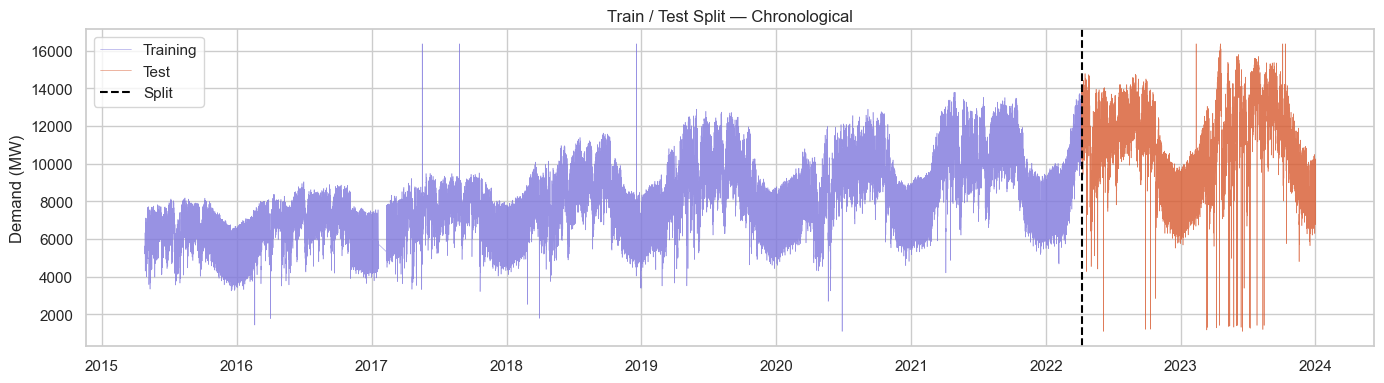

In [17]:
DROP_FROM_FEATURES = ["datetime", "demand_mw", "generation_mw", "load_shedding", "year_month"]

feature_cols = [
    c for c in df_scaled.columns
    if c not in DROP_FROM_FEATURES
]
feature_cols = df_scaled[feature_cols].select_dtypes(include=["number"]).columns.tolist()

X = df_scaled[feature_cols].copy()
y = df_scaled["demand_mw"].copy()

# Chronological split — no shuffling to prevent data leakage
split_idx = int(len(df_scaled) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Features : {X.shape[1]}")
print(f"Train    : {len(X_train):,} rows  ({len(X_train)/len(df_scaled)*100:.0f}%)")
print(f"Test     : {len(X_test):,} rows   ({len(X_test)/len(df_scaled)*100:.0f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_scaled["datetime"].iloc[:split_idx], y_train,
        color="#7F77DD", linewidth=0.4, label="Training", alpha=0.8)
ax.plot(df_scaled["datetime"].iloc[split_idx:], y_test,
        color="#D85A30", linewidth=0.4, label="Test", alpha=0.8)
ax.axvline(df_scaled["datetime"].iloc[split_idx], color="black",
           linestyle="--", linewidth=1.5, label="Split")
ax.set_title("Train / Test Split — Chronological")
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Train & Compare Models

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=150, max_depth=12, min_samples_split=20,
        min_samples_leaf=10, max_features=0.6, n_jobs=-1, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=20, random_state=42
    ),
}

results = {}

print(f"{'Model':<25} {'Time':>8} {'R2':>8} {'MAE':>10} {'RMSE':>10} {'MAPE%':>8}")
print("-" * 73)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results[name] = dict(model=model, predictions=y_pred,
                         r2=r2, mae=mae, rmse=rmse, mape=mape, time=elapsed)
    print(f"{name:<25} {elapsed:>6.1f}s {r2:>8.4f} {mae:>10.1f} {rmse:>10.1f} {mape:>7.2f}%")

Model                         Time       R2        MAE       RMSE    MAPE%
-------------------------------------------------------------------------


Linear Regression            0.3s   0.9049      301.1      683.5    3.91%
Ridge Regression             0.1s   0.9051      301.0      682.7    3.91%
Decision Tree                5.1s   0.6561      751.6     1299.6    7.31%
Random Forest               47.2s   0.8291      587.4      916.2    6.01%
Gradient Boosting          328.9s   0.7802      705.8     1039.1    7.03%


### 3.3 Visualise Results

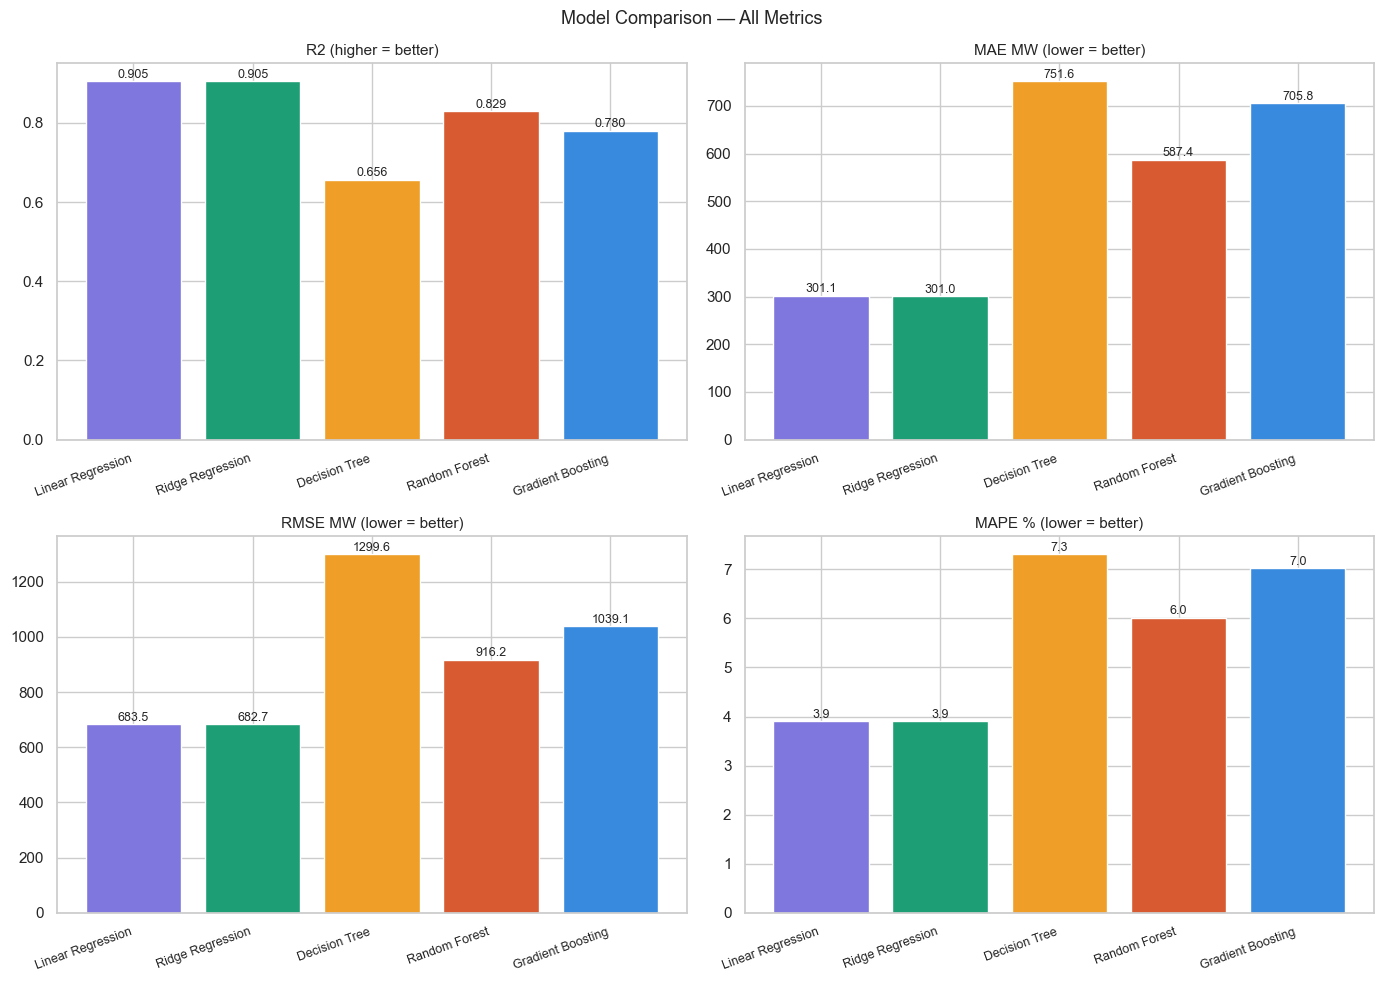

In [19]:
metrics       = ["r2", "mae", "rmse", "mape"]
metric_labels = ["R2 (higher = better)", "MAE MW (lower = better)",
                 "RMSE MW (lower = better)", "MAPE % (lower = better)"]
model_names   = list(results.keys())
palette       = ["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30", "#378ADD"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    vals = [results[n][metric] for n in model_names]
    bars = axes[i].bar(model_names, vals, color=palette, edgecolor="white")
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(vals) * 0.01,
                     f"{val:.3f}" if metric == "r2" else f"{val:.1f}",
                     ha="center", fontsize=9)

plt.suptitle("Model Comparison — All Metrics", fontsize=13)
plt.tight_layout()
plt.show()

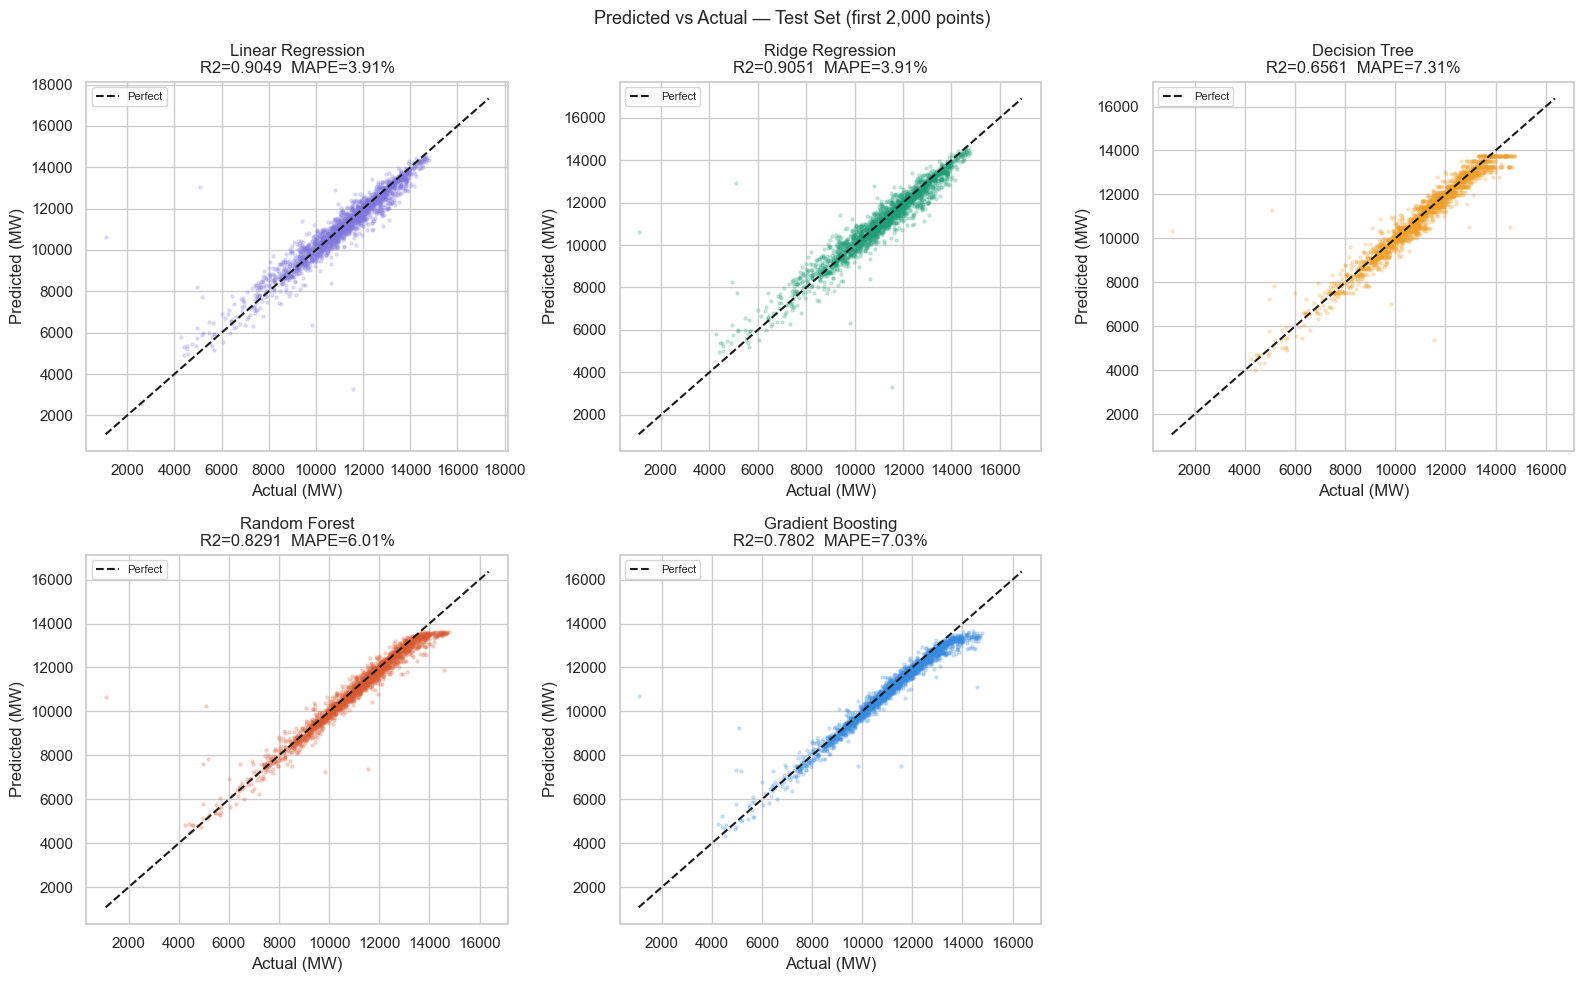

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    axes[i].scatter(y_test[:2000], res["predictions"][:2000],
                    alpha=0.2, s=5, color=palette[i])
    mn = min(y_test.min(), res["predictions"].min())
    mx = max(y_test.max(), res["predictions"].max())
    axes[i].plot([mn, mx], [mn, mx], "k--", linewidth=1.5, label="Perfect")
    axes[i].set_title(f"{name}\nR2={res['r2']:.4f}  MAPE={res['mape']:.2f}%")
    axes[i].set_xlabel("Actual (MW)")
    axes[i].set_ylabel("Predicted (MW)")
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle("Predicted vs Actual — Test Set (first 2,000 points)", fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 Feature Importance

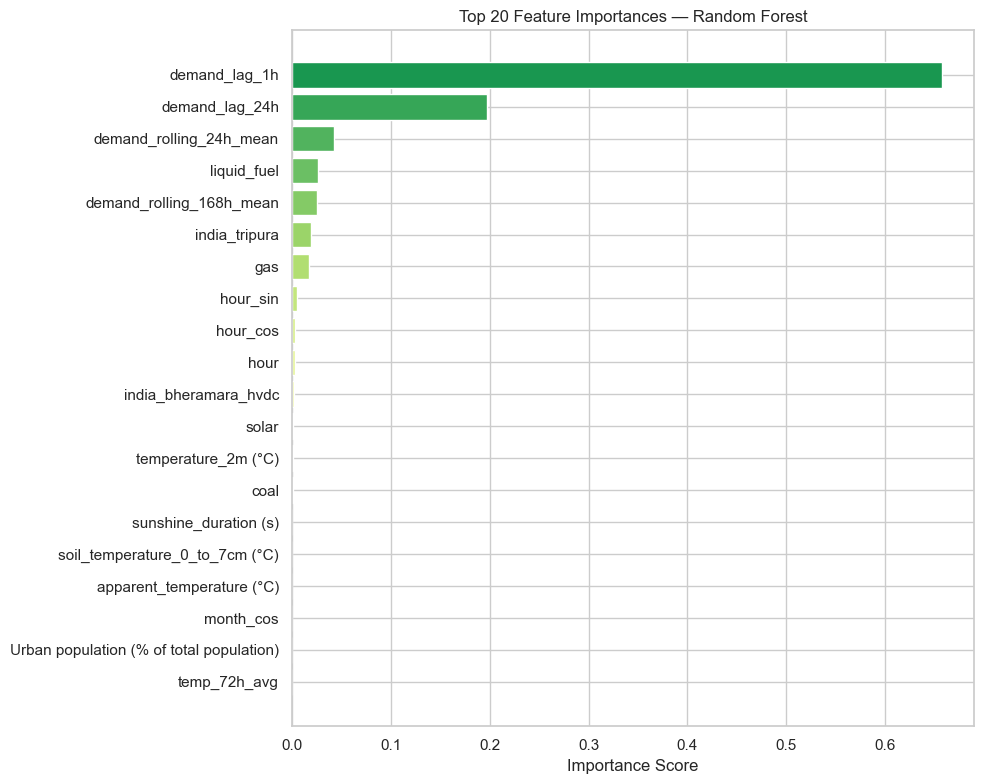

Top 10 features:
demand_lag_1h               0.6571
demand_lag_24h              0.1970
demand_rolling_24h_mean     0.0422
liquid_fuel                 0.0262
demand_rolling_168h_mean    0.0250
india_tripura               0.0191
gas                         0.0167
hour_sin                    0.0048
hour_cos                    0.0029
hour                        0.0025


In [21]:
rf_model    = results["Random Forest"]["model"]
importances = pd.Series(
    rf_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
fi_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
ax.barh(importances.index, importances.values, color=fi_colors)
ax.set_title("Top 20 Feature Importances — Random Forest")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.sort_values(ascending=False).head(10).round(4).to_string())

### 3.5 Select & Save Best Model

In [22]:
sorted_results = sorted(results.items(), key=lambda x: x[1]["r2"], reverse=True)

print(f"{'Model':<25} {'R2':>8} {'MAE':>10} {'RMSE':>10} {'MAPE%':>8}")
print("-" * 65)
for rank, (name, res) in enumerate(sorted_results, 1):
    tag = "  <- BEST" if rank == 1 else ""
    print(f"{name:<25} {res['r2']:>8.4f} {res['mae']:>10.1f} "
          f"{res['rmse']:>10.1f} {res['mape']:>7.2f}%{tag}")

best_name = sorted_results[0][0]
best_model = results[best_name]["model"]

with open("best_model.pkl", "wb") as f:
    pickle.dump({
        "model": best_model, "scaler": scaler,
        "features": feature_cols, "model_name": best_name,
    }, f)

print(f"\nSaved best_model.pkl  ({best_name})")

Model                           R2        MAE       RMSE    MAPE%
-----------------------------------------------------------------
Ridge Regression            0.9051      301.0      682.7    3.91%  <- BEST
Linear Regression           0.9049      301.1      683.5    3.91%
Random Forest               0.8291      587.4      916.2    6.01%
Gradient Boosting           0.7802      705.8     1039.1    7.03%
Decision Tree               0.6561      751.6     1299.6    7.31%

Saved best_model.pkl  (Ridge Regression)


---
## Section 4 — Cross-Validation & Hyperparameter Tuning

### 4.1 Load Preprocessed Data

In [23]:
df = pd.read_csv("preprocessed_data.csv", parse_dates=["datetime"])

DROP_FROM_FEATURES = ["datetime", "demand_mw", "generation_mw", "load_shedding", "year_month"]
feature_cols = [c for c in df.columns if c not in DROP_FROM_FEATURES]
X = df[feature_cols].select_dtypes(include=["number"]).copy()
feature_cols = X.columns.tolist()
y = df["demand_mw"].copy()

with open("best_model.pkl", "rb") as f:
    saved_selection = pickle.load(f)
scaler = saved_selection["scaler"]

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows | Features: {X.shape[1]}")

Train: 17,701 rows | Test: 4,426 rows | Features: 48


### 4.2 Baseline & Overfitting Check

Metric              Value
--------------------------
Train R²           0.9917
Test R²            0.9330
Gap                0.0587  OK
MAE (MW)            148.3
MAPE (%)             1.94


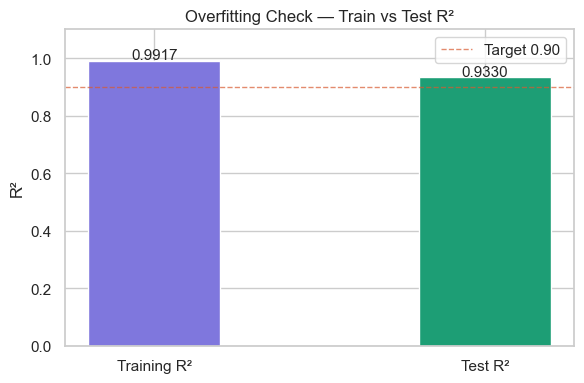

In [24]:
base_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features=0.6,
    n_jobs=-1,
    random_state=42,
)
base_model.fit(X_train, y_train)

y_pred_train_base = base_model.predict(X_train)
y_pred_base       = base_model.predict(X_test)

r2_train_base = r2_score(y_train, y_pred_train_base)
r2_base       = r2_score(y_test,  y_pred_base)
mae_base      = mean_absolute_error(y_test, y_pred_base)
mape_base     = mean_absolute_percentage_error(y_test, y_pred_base) * 100
gap_base      = r2_train_base - r2_base

print(f"{'Metric':<14} {'Value':>10}")
print("-" * 26)
print(f"{'Train R²':<14} {r2_train_base:>10.4f}")
print(f"{'Test R²':<14} {r2_base:>10.4f}")
print(f"{'Gap':<14} {gap_base:>10.4f}  {'OK' if gap_base < 0.10 else 'Overfitting'}")
print(f"{'MAE (MW)':<14} {mae_base:>10.1f}")
print(f"{'MAPE (%)':<14} {mape_base:>10.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Training R²", "Test R²"], [r2_train_base, r2_base],
              color=["#7F77DD", "#1D9E75"], width=0.4, edgecolor="white")
for bar, val in zip(bars, [r2_train_base, r2_base]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=11)
ax.axhline(0.90, color="#D85A30", linestyle="--", linewidth=1, alpha=0.7, label="Target 0.90")
ax.set_ylim(0, 1.1)
ax.set_title("Overfitting Check — Train vs Test R²")
ax.set_ylabel("R²")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Time Series Cross-Validation

Cross-Validation R2 (TimeSeriesSplit, 5 folds):
  Fold 1: 0.9637
  Fold 2: 0.9643
  Fold 3: 0.9684
  Fold 4: 0.9779
  Fold 5: 0.9248
  Mean : 0.9598
  Std  : 0.0182


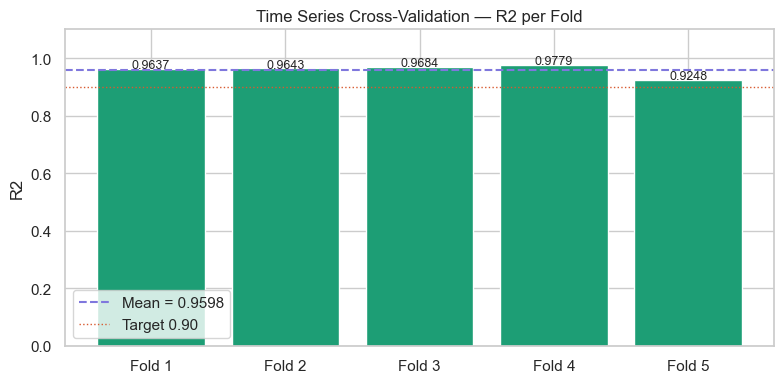

In [25]:
tscv = TimeSeriesSplit(n_splits=5)

cv_model = RandomForestRegressor(
    n_estimators=150, max_depth=12, min_samples_split=30,
    min_samples_leaf=15, max_features=0.6, n_jobs=-1, random_state=42,
)

cv_scores = cross_val_score(cv_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print(f"Cross-Validation R2 (TimeSeriesSplit, 5 folds):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
fold_labels = [f"Fold {i}" for i in range(1, len(cv_scores) + 1)]
bar_colors  = ["#1D9E75" if s >= 0.85 else "#EF9F27" if s >= 0.75 else "#E24B4A"
               for s in cv_scores]
bars = ax.bar(fold_labels, cv_scores, color=bar_colors, edgecolor="white")
ax.axhline(cv_scores.mean(), color="#7F77DD", linestyle="--",
           linewidth=1.5, label=f"Mean = {cv_scores.mean():.4f}")
ax.axhline(0.90, color="#D85A30", linestyle=":", linewidth=1, label="Target 0.90")
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Time Series Cross-Validation — R2 per Fold")
ax.set_ylabel("R2")
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Hyperparameter Tuning (GridSearchCV)

In [26]:
param_grid = {
    "n_estimators":     [150, 300],
    "max_depth":        [8, 10, 12],
    "min_samples_leaf": [10, 20, 30],
    "max_features":     [0.5, 0.7],
}

tscv_tune = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid,
    cv=tscv_tune,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
print(f"\nCompleted in {(time.time() - t0) / 60:.1f} minutes")
print(f"Best CV R2  : {grid_search.best_score_:.4f}")
print("Best params :")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Completed in 28.0 minutes
Best CV R2  : 0.9722
Best params :
  max_depth: 12
  max_features: 0.7
  min_samples_leaf: 10
  n_estimators: 150


### 4.5 Evaluate Tuned Model

Metric               Base      Tuned      Delta
----------------------------------------------
Train R2           0.9917     0.9932
Test R2            0.9330     0.9371    +0.0040
Gap                0.0587     0.0562
MAE (MW)            148.3      140.9       -7.4
MAPE (%)             1.94       1.85      -0.09


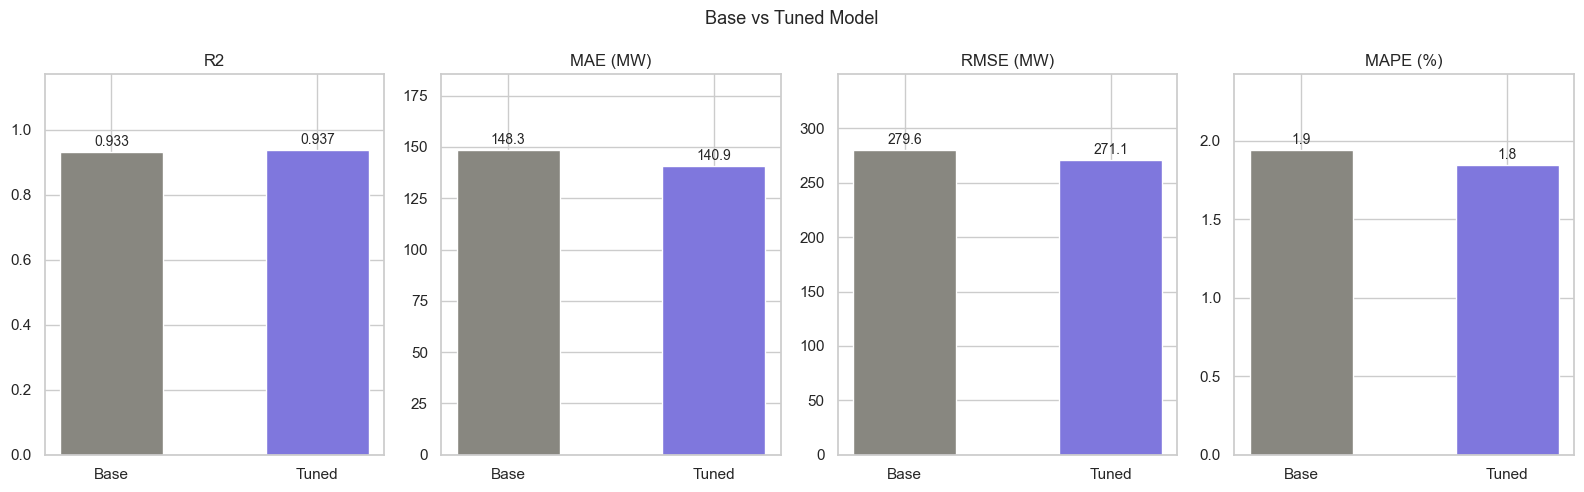

In [27]:
tuned_model = grid_search.best_estimator_

y_pred_train_tuned = tuned_model.predict(X_train)
y_pred_tuned       = tuned_model.predict(X_test)

r2_train_tuned = r2_score(y_train, y_pred_train_tuned)
r2_tuned       = r2_score(y_test,  y_pred_tuned)
mae_tuned      = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned     = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mape_tuned     = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100
gap_tuned      = r2_train_tuned - r2_tuned

print(f"{'Metric':<14} {'Base':>10} {'Tuned':>10} {'Delta':>10}")
print("-" * 46)
print(f"{'Train R2':<14} {r2_train_base:>10.4f} {r2_train_tuned:>10.4f}")
print(f"{'Test R2':<14} {r2_base:>10.4f} {r2_tuned:>10.4f} {r2_tuned - r2_base:>+10.4f}")
print(f"{'Gap':<14} {gap_base:>10.4f} {gap_tuned:>10.4f}")
print(f"{'MAE (MW)':<14} {mae_base:>10.1f} {mae_tuned:>10.1f} {mae_tuned - mae_base:>+10.1f}")
print(f"{'MAPE (%)':<14} {mape_base:>10.2f} {mape_tuned:>10.2f} {mape_tuned - mape_base:>+10.2f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
base_vals  = [r2_base, mae_base, np.sqrt(mean_squared_error(y_test, y_pred_base)), mape_base]
tuned_vals = [r2_tuned, mae_tuned, rmse_tuned, mape_tuned]
labels     = ["R2", "MAE (MW)", "RMSE (MW)", "MAPE (%)"]

for i, (label, bv, tv) in enumerate(zip(labels, base_vals, tuned_vals)):
    axes[i].bar(["Base", "Tuned"], [bv, tv],
                color=["#888780", "#7F77DD"], edgecolor="white", width=0.5)
    for j, val in enumerate([bv, tv]):
        axes[i].text(j, val * 1.02,
                     f"{val:.3f}" if label == "R2" else f"{val:.1f}",
                     ha="center", fontsize=10)
    axes[i].set_title(label)
    axes[i].set_ylim(0, max(bv, tv) * 1.25)

plt.suptitle("Base vs Tuned Model", fontsize=13)
plt.tight_layout()
plt.show()

### 4.6 Final Evaluation

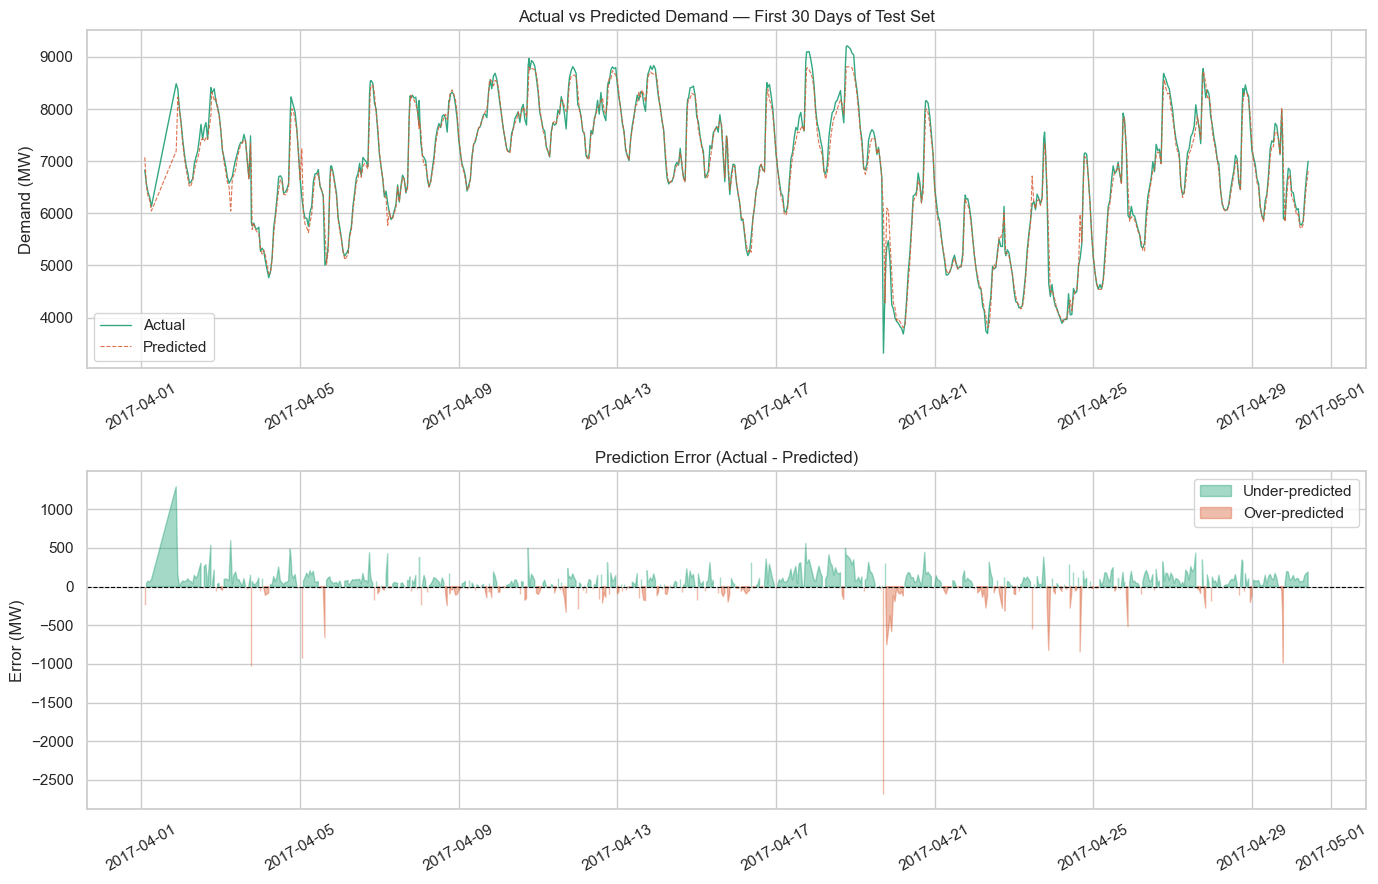

In [28]:
sample_size   = 24 * 30
actual_sample = y_test.values[:sample_size]
pred_sample   = y_pred_tuned[:sample_size]
dates_sample  = df["datetime"].iloc[split_idx : split_idx + sample_size]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(dates_sample, actual_sample,
             color="#1D9E75", linewidth=1.0, label="Actual", alpha=0.9)
axes[0].plot(dates_sample, pred_sample,
             color="#D85A30", linewidth=0.8, label="Predicted",
             alpha=0.85, linestyle="--")
axes[0].set_title("Actual vs Predicted Demand — First 30 Days of Test Set")
axes[0].set_ylabel("Demand (MW)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

errors = actual_sample - pred_sample
axes[1].fill_between(dates_sample, errors, 0,
                     where=(errors >= 0), color="#1D9E75",
                     alpha=0.4, label="Under-predicted")
axes[1].fill_between(dates_sample, errors, 0,
                     where=(errors < 0), color="#D85A30",
                     alpha=0.4, label="Over-predicted")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Prediction Error (Actual - Predicted)")
axes[1].set_ylabel("Error (MW)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

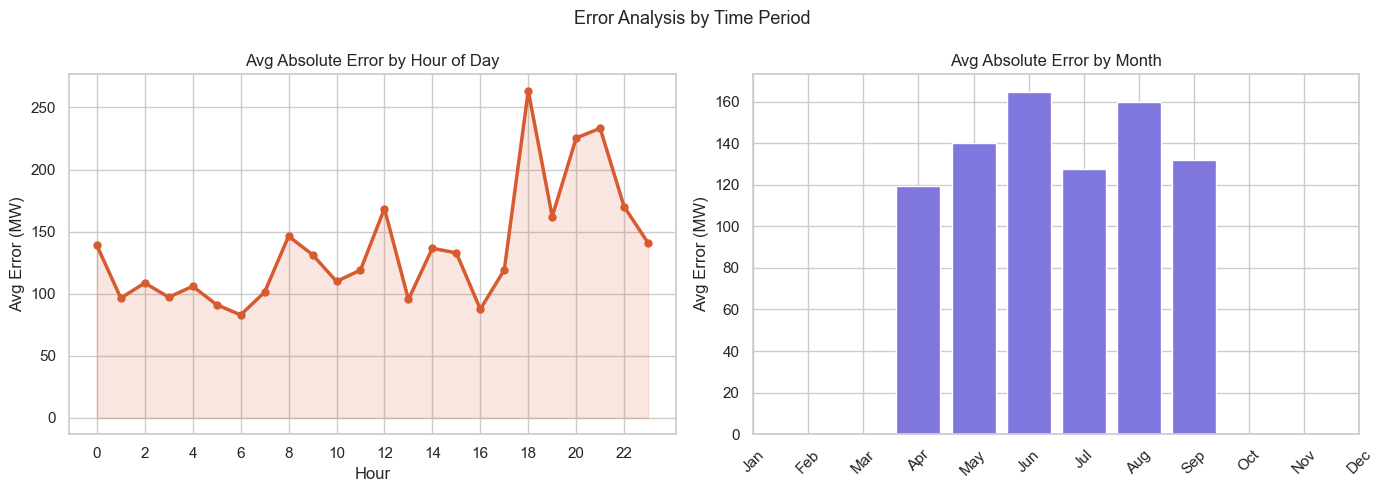

In [29]:
df_eval = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": y_pred_tuned,
    "error":     np.abs(y_test.values - y_pred_tuned),
    "hour":      df["datetime"].iloc[split_idx:].dt.hour.values,
    "month":     df["datetime"].iloc[split_idx:].dt.month.values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_err = df_eval.groupby("hour")["error"].mean()
axes[0].plot(hourly_err.index, hourly_err.values,
             color="#D85A30", linewidth=2.5, marker="o", markersize=5)
axes[0].fill_between(hourly_err.index, hourly_err.values, alpha=0.15, color="#D85A30")
axes[0].set_title("Avg Absolute Error by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Error (MW)")
axes[0].set_xticks(range(0, 24, 2))

monthly_err = df_eval.groupby("month")["error"].mean()
axes[1].bar(monthly_err.index, monthly_err.values, color="#7F77DD", edgecolor="white")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title("Avg Absolute Error by Month")
axes[1].set_ylabel("Avg Error (MW)")

plt.suptitle("Error Analysis by Time Period", fontsize=13)
plt.tight_layout()
plt.show()

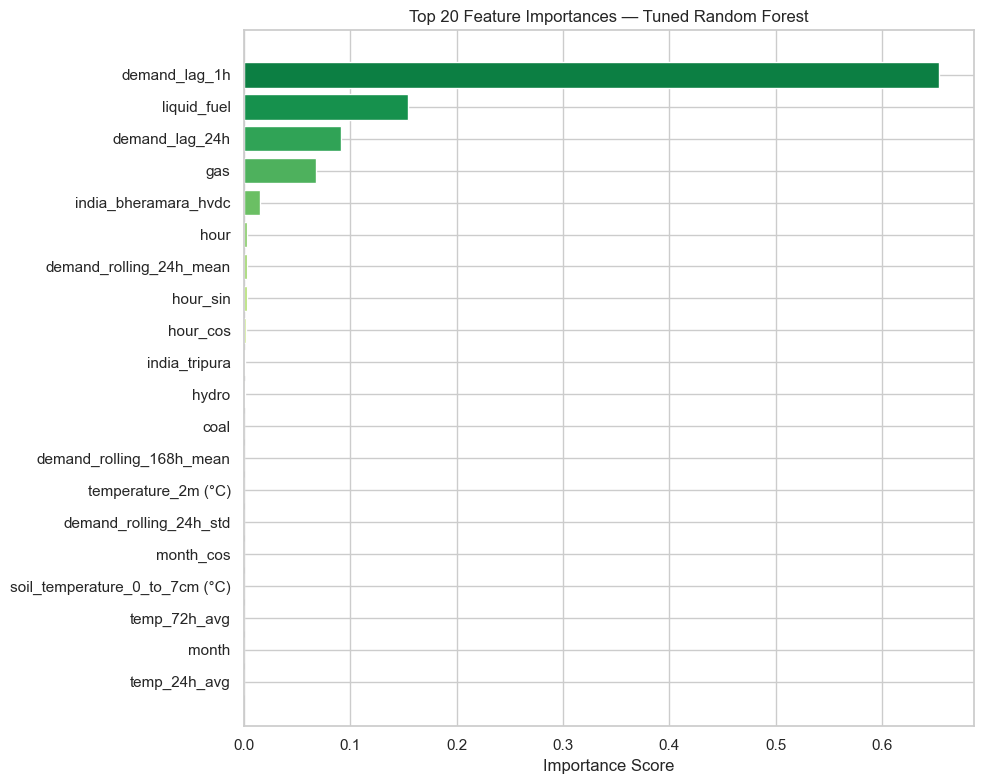

Top 10 features:
demand_lag_1h              0.6536
liquid_fuel                0.1543
demand_lag_24h             0.0911
gas                        0.0681
india_bheramara_hvdc       0.0154
hour                       0.0033
demand_rolling_24h_mean    0.0028
hour_sin                   0.0025
hour_cos                   0.0025
india_tripura              0.0015


In [30]:
importances = pd.Series(
    tuned_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
fi_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.95, len(importances)))
ax.barh(importances.index, importances.values, color=fi_colors)
ax.set_title("Top 20 Feature Importances — Tuned Random Forest")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.sort_values(ascending=False).head(10).round(4).to_string())

### 4.7 Save Final Model

In [31]:
final_save = {
    "model":       tuned_model,
    "scaler":      scaler,
    "features":    feature_cols,
    "model_name":  "Random Forest (Tuned)",
    "metrics": {
        "r2":   round(r2_tuned,   4),
        "mae":  round(mae_tuned,  2),
        "rmse": round(rmse_tuned, 2),
        "mape": round(mape_tuned, 2),
    },
    "best_params":  grid_search.best_params_,
    "train_period": str(df["datetime"].iloc[0].date()),
    "test_period":  str(df["datetime"].iloc[split_idx].date()),
}

with open("final_model.pkl", "wb") as f:
    pickle.dump(final_save, f)

print("Saved final_model.pkl")
print(f"  R2   = {r2_tuned:.4f}")
print(f"  MAE  = {mae_tuned:.1f} MW")
print(f"  RMSE = {rmse_tuned:.1f} MW")
print(f"  MAPE = {mape_tuned:.2f}%")

Saved final_model.pkl
  R2   = 0.9371
  MAE  = 140.9 MW
  RMSE = 271.1 MW
  MAPE = 1.85%


---
## Section 5 — Pipeline Summary

In [32]:
print(f"Dataset        : {len(df):,} rows | {len(feature_cols)} features")
print(f"Train          : {len(X_train):,} rows (80%)")
print(f"Test           : {len(X_test):,} rows (20%)")
print()
print(f"CV Mean R2     : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Best params    : {grid_search.best_params_}")
print()
print(f"Final R2       : {r2_tuned:.4f}")
print(f"Final MAE      : {mae_tuned:.1f} MW")
print(f"Final RMSE     : {rmse_tuned:.1f} MW")
print(f"Final MAPE     : {mape_tuned:.2f}%")
print()
print(f"Train/Test Gap : {r2_train_tuned - r2_tuned:.4f}  "
      f"({'No overfitting' if r2_train_tuned - r2_tuned < 0.10 else 'Mild overfitting'})")

Dataset        : 22,127 rows | 48 features
Train          : 17,701 rows (80%)
Test           : 4,426 rows (20%)

CV Mean R2     : 0.9598 +/- 0.0182
Best params    : {'max_depth': 12, 'max_features': 0.7, 'min_samples_leaf': 10, 'n_estimators': 150}

Final R2       : 0.9371
Final MAE      : 140.9 MW
Final RMSE     : 271.1 MW
Final MAPE     : 1.85%

Train/Test Gap : 0.0562  (No overfitting)
